In [4]:
# EDA Mini Project - Netflix Movies and TV Shows Dataset
# Dataset: Netflix Shows from Kaggle
# Link: https://www.kaggle.com/datasets/shivamb/netflix-shows
#
# About the dataset:
# This dataset contains information about movies and TV shows
# available on Netflix as of 2021. It has 8807 rows and 12 columns
# including title, director, cast, country, release year, rating,
# duration and genre (listed_in).
#
# Why this dataset?
# Netflix is one of the world's largest streaming platforms.
# Analyzing this data helps us understand content trends,
# popular genres, country-wise content production, and
# how Netflix has grown over the years.

In [5]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Load the Netflix dataset
df = pd.read_csv('netflix_titles.csv')
print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
# Check data types of each column
print("Data Types:")
print(df.dtypes)

Data Types:
show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object


In [7]:
# Basic statistical summary
print("Basic Statistics:")
print(df.describe(include='all'))

Basic Statistics:
       show_id   type                 title       director  \
count     8807   8807                  8807           6173   
unique    8807      2                  8807           4528   
top         s1  Movie  Dick Johnson Is Dead  Rajiv Chilaka   
freq         1   6131                     1             19   
mean       NaN    NaN                   NaN            NaN   
std        NaN    NaN                   NaN            NaN   
min        NaN    NaN                   NaN            NaN   
25%        NaN    NaN                   NaN            NaN   
50%        NaN    NaN                   NaN            NaN   
75%        NaN    NaN                   NaN            NaN   
max        NaN    NaN                   NaN            NaN   

                      cast        country       date_added  release_year  \
count                 7982           7976             8797   8807.000000   
unique                7692            748             1767           NaN   
top     D

In [8]:
# Check missing values
print("Missing values per column:")
print(df.isnull().sum())
print("\nMissing value percentage:")
print(round((df.isnull().sum() / len(df)) * 100, 2))

Missing values per column:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Missing value percentage:
show_id          0.00
type             0.00
title            0.00
director        29.91
cast             9.37
country          9.44
date_added       0.11
release_year     0.00
rating           0.05
duration         0.03
listed_in        0.00
description      0.00
dtype: float64


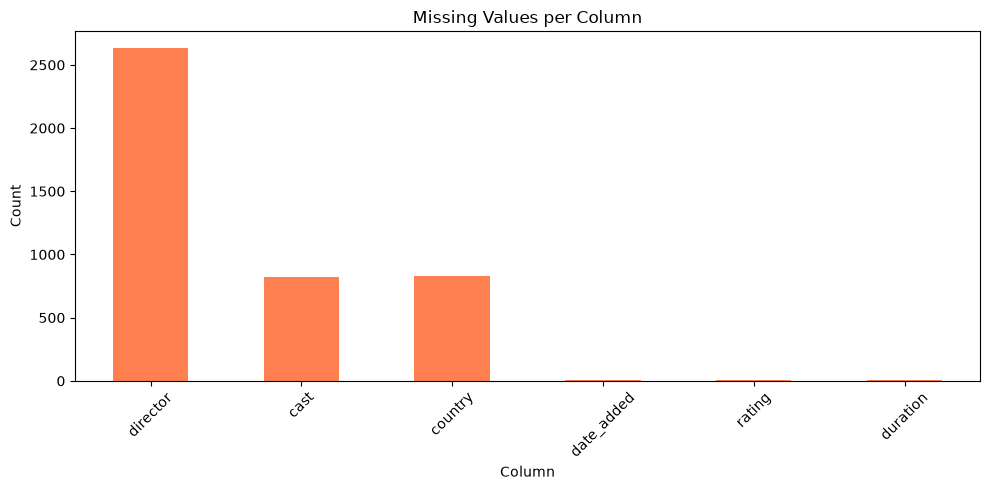

In [9]:
# Visualize missing values
missing = df.isnull().sum()
missing = missing[missing > 0]

missing.plot(kind='bar', color='coral', figsize=(10, 5))
plt.title('Missing Values per Column')
plt.ylabel('Count')
plt.xlabel('Column')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Handle missing values

df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['date_added'] = df['date_added'].fillna('Unknown')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['duration'] = df['duration'].fillna('Unknown')

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
dtype: int64


In [11]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Duplicate rows: 0
Shape after removing duplicates: (8807, 12)


In [12]:
# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
print("Date column converted successfully!")
print(df[['date_added', 'year_added', 'month_added']].head())

Date column converted successfully!
  date_added  year_added  month_added
0 2021-09-25      2021.0          9.0
1 2021-09-24      2021.0          9.0
2 2021-09-24      2021.0          9.0
3 2021-09-24      2021.0          9.0
4 2021-09-24      2021.0          9.0


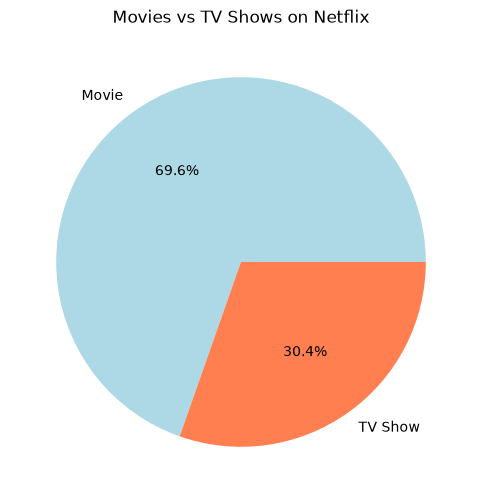

In [ ]:
# Graph 1 - Content type distribution
content_counts = df['type'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(content_counts, labels=content_counts.index,
        autopct='%1.1f%%', colors=['lightblue', 'coral'])
plt.title('Movies vs TV Shows on Netflix')
plt.show()
#### Observation 
# The pie chart shows that Movies make up the majority of Netflix's content, while TV Shows represent a smaller proportion. 
#This indicates that the Netflix dataset contains significantly more movies than TV shows.

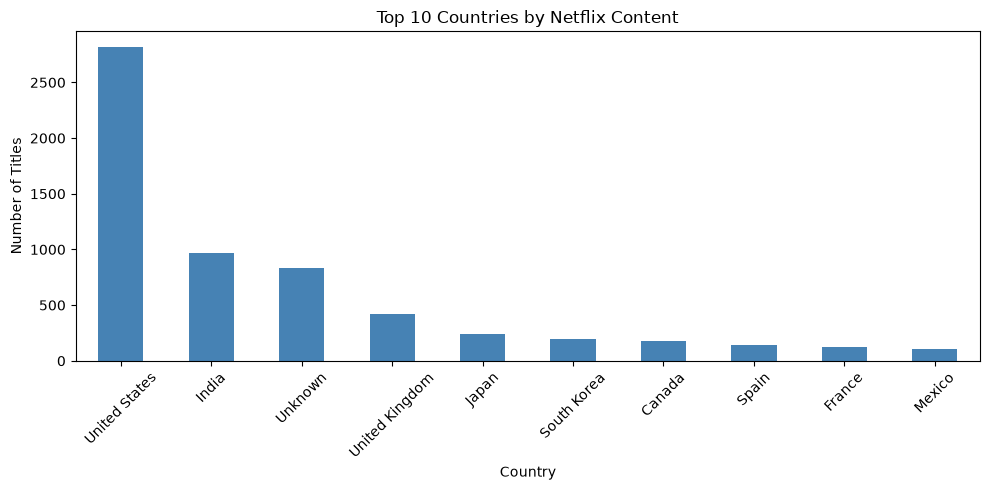

In [ ]:
# Graph 2 - Top 10 countries producing content
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_countries.plot(kind='bar', color='steelblue')
plt.title('Top 10 Countries by Netflix Content')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
#The bar chart shows that the United States has the highest number of titles in the dataset.
#  Other countries contribute considerably fewer titles, 
# showing that Netflix's content library has a strong contribution from the United States.

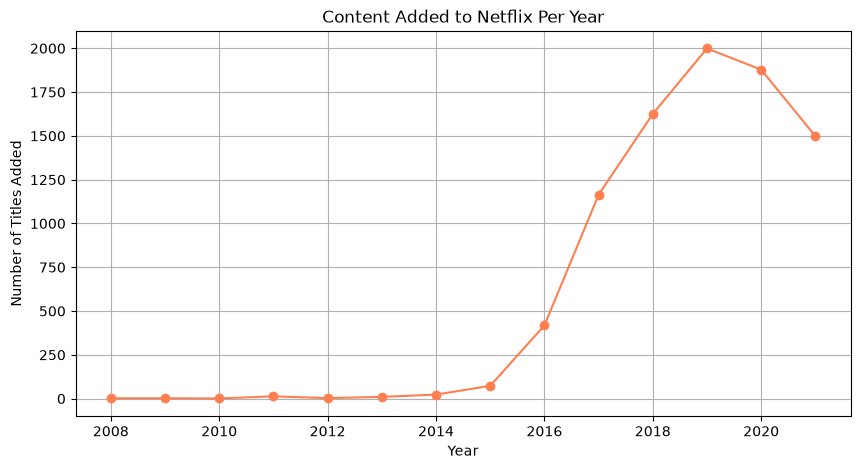

In [ ]:
# Graph 3 - Content added to Netflix per year
yearly = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(yearly.index, yearly.values, marker='o', color='coral')
plt.title('Content Added to Netflix Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.grid(True)
plt.show()
#The graph shows that Netflix added relatively few titles in the earlier years, followed by a strong increase in content additions in the later years.
#  The number of additions varies across years, showing changes in Netflix's content expansion over time.

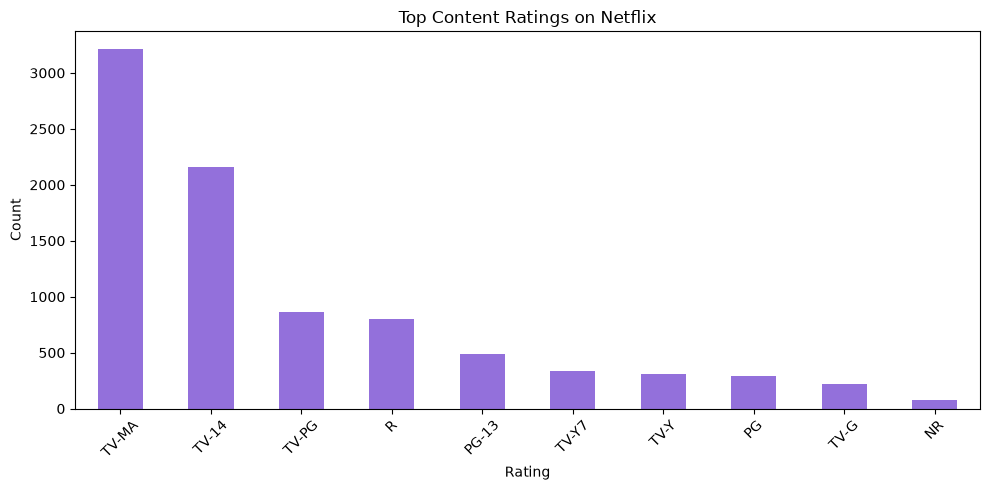

In [ ]:
# Graph 4 - Content rating distribution
rating_counts = df['rating'].value_counts().head(10)

plt.figure(figsize=(10, 5))
rating_counts.plot(kind='bar', color='mediumpurple')
plt.title('Top Content Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
#The bar chart shows that TV-MA is the most common content rating in the dataset.
#  Other ratings occur less frequently, indicating that mature-rated content represents a large portion of the Netflix titles included in this dataset.

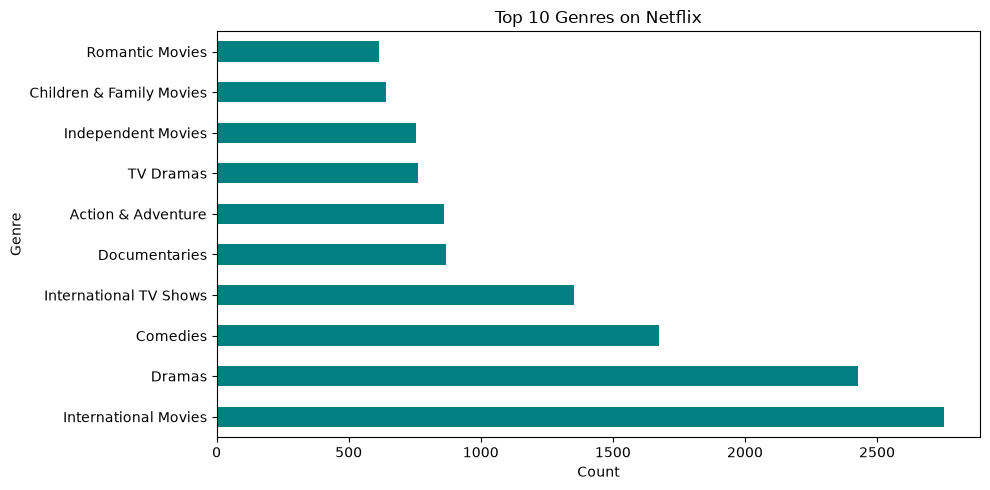

In [ ]:
# Graph 5 - Top 10 genres on Netflix
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10, 5))
top_genres.plot(kind='barh', color='teal')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()
#The bar chart shows that International Movies, Dramas, and Comedies are among the most common genres in the dataset. 
# This indicates that Netflix has a diverse content library with a strong presence of international and drama-related content.

In [ ]:
# Final Conclusion

print("""
FINAL CONCLUSION - Netflix EDA
==============================

1. Content Type:
   Movies make up the majority of the Netflix titles in the dataset,
   while TV Shows represent a smaller proportion.

2. Country:
   The United States has the highest number of titles among the
   countries represented in the dataset.

3. Growth:
   Netflix's content additions increased significantly over the years,
   with noticeable variation in the number of titles added each year.

4. Ratings:
   TV-MA is the most common content rating, showing that mature-rated
   content forms a large portion of the dataset.

5. Genres:
   International Movies, Dramas, and Comedies are among the most common
   genres, showing the diversity of Netflix's content library.

6. Preprocessing:
   Missing values were identified and handled, duplicate records were
   checked, and the date_added column was converted to datetime.
   Additional year and month columns were created for trend analysis.
""")


FINAL CONCLUSION - Netflix EDA

1. Content Type: Netflix has more Movies (70%) than TV Shows (30%).
   Movies dominate the platform.

2. Country: USA is the top content producer. India is second,
   showing Netflix's strong investment in Indian content.

3. Growth: Netflix grew rapidly from 2016-2019. COVID-19 slowed
   new content additions after 2020.

4. Ratings: Most content is rated TV-MA (mature). Netflix
   primarily targets adult audiences.

5. Genres: International Movies and Dramas are most common.
   Netflix has a strong global and drama-focused library.

6. Preprocessing: We handled missing values in Director, Cast,
   Country and Rating columns. Date column was converted to
   datetime for trend analysis.

